### Purpose
Making the spherical intensity slice plots once again, after fixing a number of longitude lines to sample at and projecting them up to each altitude, along with the restriction box. Should be giving a more accurate altitude projection matrix; need to sniff out suspicious behavior in the plots so this is a sanity check lol. 

What changes need to be made?
Right now, the plots are just for taking a slice at a longitude, with the longitude line properly projected. 
Sooo shouldn't they be the same plots? Maybe just double check first that we are using the same number of points for comparison with each plot. 

TODO:
- fix the number of points being used for each altitude
- make the new spherical intensity slice plots with the latitude projected as well (only projecting the longitude at the moment, need to define a set of points like doing here then should be pretty plug and play)
- get the plot for the 10 UTC event 

### Imports

In [1]:
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import xarray as xr

#for dealing with files:
import os
import re
from scipy.io import readsav
import h5py
import requests
from bs4 import BeautifulSoup
from tqdm import tqdm
from urllib.parse import urljoin, urlparse
import time

#for plotting (the rcParams updates are my personal perference to change font and increase fontsize)
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import ListedColormap
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams.update({'font.size': 24,\
                     'xtick.labelsize' : 24,\
                     'ytick.labelsize' : 24,\
                     'axes.titlesize' : 24,\
                     'axes.labelsize' : 24,\
                     'date.autoformatter.minute': '%H:%M' })

import skymap_data_helper # all helper functions for downloading and parsing data
import cv2 # for contrast adjustment
from PIL import Image # for resolution increase
import importlib
importlib.reload(skymap_data_helper)
import math

from scipy.interpolate import griddata
from scipy.stats import pearsonr
from PIL import Image
from scipy.stats import pearsonr # correlation

import os # folder stuff 

import threading
import time 

from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
from functools import partial
from tqdm.notebook import tqdm # since in jupyter

import altitude_helper
import importlib
importlib.reload(altitude_helper)

<module 'altitude_helper' from '/home/molidae/Desktop/berkeley/STEVE2.0/altitude_helper.py'>

### Load Data

In [2]:
#load an hour of data
site_yknf = 'yknf'
site_fsmi = 'fsmi'
date = datetime(2024,8,30)
hour = 5 #this is in UT

rgb_asi_skymap_lookup_df = skymap_data_helper.build_rgb_asi_skymap_lookup_table(directory='./trex-rgb-asi_data') #CHANGE TO YOUR SKYMAP DIRECTORY!
yknf_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_yknf, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!
fsmi_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_fsmi, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!


/home/molidae/Desktop/berkeley/STEVE2.0/skymap_data_helper.py:273: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["valid_end"] = df["valid_end"].fillna(pd.to_datetime(datetime.utcnow().date()))  # today at midnight UTC


Skymap file:
rgb_skymap_yknf_20240829-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_yknf_20240829-%2B_v01.sav
Skymap file:
rgb_skymap_fsmi_20240808-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_fsmi_20240808-%2B_v01.sav


### Interpolation w/ Fixed Lon

In [3]:
''' Fix number of projecting points at 150km, and project upwards from there so have constant number of longitudes and latitudes'''
def new_get_intensity_slice(lat_proj, lon_proj, rgb, 
                        lat_max_box, lat_min_box, lon_max_box, lon_min_box, # dont actually need these boxes, just placeholder so can get function to work
                         lat_camera, lon_camera,
                         site_name, time_index, 
                         og_h, new_h,
                         global_lon_arr, global_lat_arr):

    """
    Given projected latitude and longitude arrays and a particular longitude to slice at (put this particular longitude is relative to 100km proj,
    put it into global_lon_arr as a single element array)
    Find the intensities for the latitudes along this longitude slice  (projected up to new_h, common across both cameras).
    Baseline global_lon_arr and global_lat_arr from 100km (og_h), then projected upwards to new_h. 

    Need to put baseline at 100km because want to see broad range of how the fsmi and yknf peak 
    Use 247.95 degrees as baseline. 

    input:
        lat_proj = 2D projected latitude arr (output of project_lat_lon())
        lon_proj = 2D projected longitude arr (output of project_lat_lon())
        rgb = 3D rgb array (output of mod_plot_lat_lon()) (these are the raw rgb values from the skymap, need to be matched to the projected new projected lat/lon
        time_index = for naming purposes when plotting 
        site_name = for naming purposes when plotting
        og_h = 150,000 km the baseline for where we determined the best longitude slices and the best lat/lon box
        new_h = new height we've projected to for the interpolation (what lat_proj and lon_proj were projected to) 

    output:
        R_peak_lat_arr = 1D arr of all the latitudes that the R-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
        G_peak_lat_arr = 1D arr of all the latitudes that the G-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
        B_peak_lat_arr = 1D arr of all the latitudes that the B-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
        lon_arr = 1D arr of all the longitudes corresponding in idx to the peak latitude arrays (should be same length as the other 3 returned arrays)
    """

    print(f"\n====={new_h/1000.0}km PROJECTION=======")
    print(f"Total {len(global_lon_arr)} longitudes, and for each of these longitudes have   {len(global_lat_arr)} latitudes to interpolate\n")

    # separate into R channel
    R = rgb[:,:, 0]

    # preallocate the sizes of the R_peak_lat_array and R_lon_arr (don't <continue> when run into issue with longitude, rather just add nan in that place)
    R_peak_lat_arr = np.full(len(global_lon_arr), np.nan)
    R_lon_arr = np.full(len(global_lon_arr), np.nan)

    # reproject the latitude slices and the bounding box for each projection --> already looping through all the lon slices here
    # don't need the bounding box for this purpose --> 4/14 CHANGED THIS TO project_lon_slices_and_box from project_lat_slices_and_box (changed the naming, bc need latitude slices for 5UT event now)
    reproj_lat_arr_dict, reproj_lon_arr_dict, reproj_left_lat, reproj_left_lon, reproj_right_lat, reproj_right_lon, reproj_bottom_lat, reproj_bottom_lon, reproj_top_lat, reproj_top_lon = altitude_helper.project_lon_slices_and_box(global_lat_arr, global_lon_arr, # these are in degrees
                                                                                                                                                                                                                           lat_max_box, lat_min_box, lon_max_box, lon_min_box, # also degrees
                                                                                                                                                                                                                           lat_camera, lon_camera, og_h, new_h)
    # LEAVE THIS WHITESPACE ALONE
    original_lon_arr = reproj_lat_arr_dict.keys() # these keys should be the same as take from reproj_lon_arr_dict, and in degrees
    reproj_lon_slice_arr = reproj_lon_arr_dict.values() # this is array of arrays of longitude corresp. to each longitude of the original slices (should just be 1 value)
    reproj_lat_slice_arr = reproj_lat_arr_dict.values() # this is array of latitude for each longiutde in reproj_lon_slice

    # preallocate
    num_slices = len(original_lon_arr)
    R_peak_lat_arr = np.full(num_slices, np.nan)
    R_lon_arr = np.full(num_slices, np.nan)# longitudes that correspond to the peak latitude 
    lon_buffer = 10 + (new_h / 100000)
    for idx, (original_lon,reproj_lat_slice, reproj_lon_slice) in enumerate(zip(original_lon_arr, reproj_lat_slice_arr, reproj_lon_slice_arr)):

        # plot the reprojected longitude slice line and the reprojected bounding box
        altitude_helper.plot_lon_slice_bounding_box(lat_proj, lon_proj, 
                                    reproj_lat_slice, reproj_lon_slice, #slice
                                    reproj_left_lat, reproj_left_lon, reproj_right_lat, reproj_right_lon, #bounding box
                                    reproj_bottom_lat, reproj_bottom_lon, reproj_top_lat, reproj_top_lon, #bounding box
                                    rgb, time_index, site_name, new_h, False)
        
        slice_mask = np.abs(lon_proj - original_lon) <= lon_buffer # might need to change this threshold depending on warp in projection
        lon_slice_points = lon_proj[slice_mask]
        lat_slice_points = lat_proj[slice_mask]
        R_slice_values = R[slice_mask] #already flattened 

        # get lat and lon slices over which to interpolate in the right shape 
        flattened_points = np.column_stack((lat_slice_points.flatten(), lon_slice_points.flatten())) # (N,2) pairs of (lat, lon)

        # masks for NaNs in R, G, and B channels separately (basically remove the NaNs and infinite values if there is) --> where the projected lat, lon, or rgb values corresponding to pixel are NaNs
        nan_mask_R = (np.isfinite(flattened_points[:,0]) & np.isfinite(flattened_points[:,1]) & np.isfinite(R_slice_values))
        points_R_clean = flattened_points[nan_mask_R]
        values_R_clean = R_slice_values[nan_mask_R]
        #print(f"Lon {original_lon}: Points captured by mask: {len(points_R_clean)}")

        # get interpolation locations (these are just the (lat,lon) pairs from the reprojected longitude slices
        interp_locations = np.column_stack((reproj_lat_slice, reproj_lon_slice))


        if len(points_R_clean) >= 3 and len(values_R_clean) >= 3:   # minimum for 2D linear interpolation
            R_intensity_profile = griddata(points_R_clean, values_R_clean, interp_locations, method='linear') #intensities along the interp_locations
        else:
            R_intensity_profile = np.full(len(interp_locations), np.nan)  # or 0

   # print(f"reproj lat slice arr: {reproj_lat_slice_arr}")
    lat_grid = list(reproj_lat_arr_dict.values())[0]
    # print(f"{site_name}{new_h} lat grid: {yknf_lat_grid}")
    # print(f"{site_name}{new_h} intensity grid: {R_intensity_profile}")
    
    return lat_grid, R_intensity_profile
    

In [4]:
def plot_intensity_slice(yknf_lat_grid, yknf_R_intensity_interp,
                        fsmi_lat_grid, fsmi_R_intensity_interp,
                        lon, h):
    """ 
    Given the latitudes and the R channel pixel intensities along some longitude slice for both yknf and fsmi, 
    make a plot showing how the intensity varies across the latitudes for each of the fsmi and yknf slices

    inputs:
        yknf_lat_grid: array of latitudes we interpolated to in get_intensity_slice for yknf
        yknf_R_intensity_interp: array of intensities for each of the latitudes above (len of R intensity = len lat grid)
        fsmi_lat_grid: equiv.
        fsmi_R_intensity_interp: equiv.
        lon: the longitude slice for which we stepped along and looked at the brightnesses at diff latitudes
        h: altitude projected to for this longitude slice

    outputs:
        plot
    """
    plt.figure(figsize=(8, 5))
    
    # Plot YKNF intensity profile
    plt.plot(np.array(yknf_lat_grid).flatten(), np.array(yknf_R_intensity_interp).flatten(), label='YKNF', color='red', marker='o', linestyle='-')
    
    # Plot FSMI intensity profile
    plt.plot(np.array(fsmi_lat_grid).flatten(), np.array(fsmi_R_intensity_interp).flatten(), label='FSMI', color='blue', marker='x', linestyle='--')
    
    plt.xlabel("Latitude (deg)")
    plt.ylabel("R-channel intensity")
    plt.title(f"{h/1000.0}km: R-channel intensity vs Latitude at longitude {lon:.2f}°")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    

In [5]:
def plot_overlaid_masked(yknf_rgb_asi_ds, fsmi_rgb_asi_ds, time_index,
                         site_name_yknf, site_name_fsmi, 
                         yknf_lat_proj, yknf_lon_proj, fsmi_lat_proj, fsmi_lon_proj,
                         h_target):
    #--------diagonal line to mask everything below for yknf-----------#
    m = 0.40
    b = -37
    yknf_lat_line = m * yknf_lon_proj + b

    diagonal_mask = yknf_lat_proj < yknf_lat_line
    keep_mask = ~diagonal_mask & np.isfinite(yknf_lat_proj) & np.isfinite(yknf_lon_proj)

    #-----------get image channels-------------#    
    R_yknf = yknf_rgb_asi_ds.image.sel(channel="R").isel(times=time_index).values
    G_yknf = yknf_rgb_asi_ds.image.sel(channel="G").isel(times=time_index).values
    B_yknf = yknf_rgb_asi_ds.image.sel(channel="B").isel(times=time_index).values
    
    R_fsmi = fsmi_rgb_asi_ds.image.sel(channel="R").isel(times=time_index).values
    G_fsmi = fsmi_rgb_asi_ds.image.sel(channel="G").isel(times=time_index).values
    B_fsmi = fsmi_rgb_asi_ds.image.sel(channel="B").isel(times=time_index).values
    
    
    #-------------extract time + format----------------#
    raw_time = yknf_rgb_asi_ds.times.values[time_index]
    time_obj = pd.to_datetime(raw_time.decode("utf-8").replace(" UTC", ""))
    time_str = time_obj.strftime("%b. %d, %Y %H:%M:%S UT")
        
    #-------------contrast adjustment: alpha=contrast, beta=brightness--------------#
    alpha = 5
    beta = 5
    rgb_yknf = np.stack([R_yknf, G_yknf, B_yknf], axis=-1)  # shape: (x, y, 3)
    rgb_fsmi = np.stack([R_fsmi, G_fsmi, B_fsmi], axis=-1)  # shape: (x, y, 3)
    
    rgb_yknf_adjusted = cv2.convertScaleAbs(rgb_yknf, alpha=alpha, beta=beta).astype(float)
    rgb_fsmi_adjusted = cv2.convertScaleAbs(rgb_fsmi, alpha=alpha, beta=beta).astype(float)

    #-----------masking yknf-------------#
    yknf_lon_masked = yknf_lon_proj[keep_mask]
    yknf_lat_masked = yknf_lat_proj[keep_mask]
    rgb_yknf_adjusted_masked = rgb_yknf_adjusted[keep_mask] # set everything below diagonal to nans 

    x_plot_min = 215
    x_plot_max = 275
    y_plot_min = 45
    y_plot_max = 80

    print("lat range:", np.nanmin(yknf_lat_proj), np.nanmax(yknf_lat_proj))
    print("lon range:", np.nanmin(yknf_lon_proj), np.nanmax(yknf_lon_proj))
    print("line range:", np.nanmin(yknf_lat_line), np.nanmax(yknf_lat_line))
    print("keep fraction:", np.mean(keep_mask))

    # overlaid 
    plt.figure(figsize=(8,8))
    plt.scatter(fsmi_lon_proj.flatten(),fsmi_lat_proj.flatten(),c=rgb_fsmi_adjusted.reshape(-1, 3)/256,s=1, alpha=1) #0.08
    plt.scatter(yknf_lon_masked.flatten(),yknf_lat_masked.flatten(),c=rgb_yknf_adjusted_masked.reshape(-1, 3)/256,s=1, alpha=1) #0.15
    plt.xlabel("Longitude (deg)")
    plt.ylabel("Latitude (deg)")
    plt.title(f"Overlaid {h_target/1000}km Projection - {time_str}", pad=30)
    plt.xlim((x_plot_min, x_plot_max))
    plt.ylim((y_plot_min, y_plot_max))
    plt.show()


In [10]:
#h_target_arr = [100000, 110000, 120000, 130000, 140000, 150000, 160000, 170000, 180000, 190000, 200000, 210000, 220000, 230000, 240000, 250000, 260000, 270000, 280000, 290000, 300000]
h_target_arr = [200000]
time_index = 251
site_name_yknf = "Yellowknife"
site_name_fsmi = "Fort Smith"
R_fsmi = fsmi_rgb_asi_ds.image.sel(channel="R").isel(times=time_index).values



=====200.0km PROJECTION=======
Total 1 longitudes, and for each of these longitudes have   63 latitudes to interpolate

lon_slice_target: 250.1030183800078


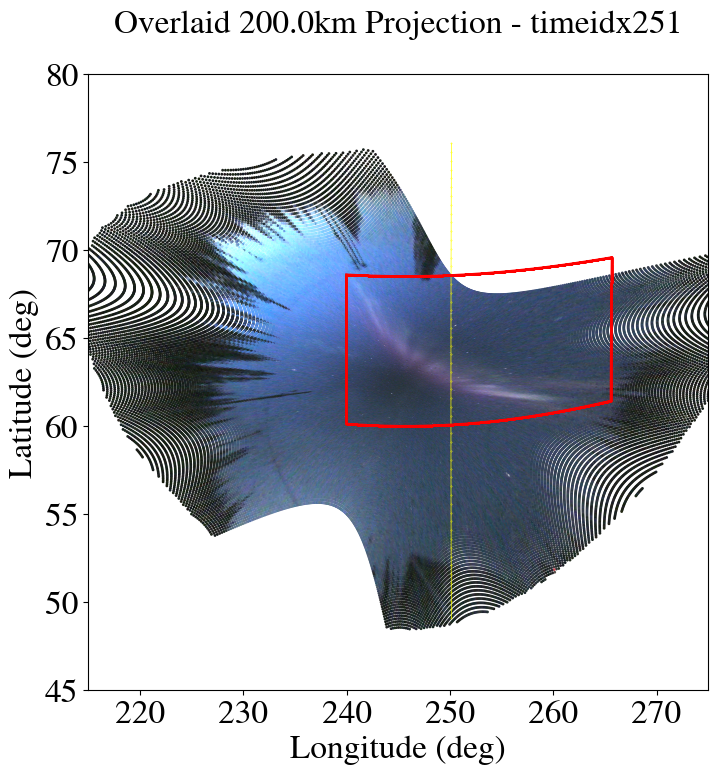


=====200.0km PROJECTION=======
Total 1 longitudes, and for each of these longitudes have   63 latitudes to interpolate

lon_slice_target: 250.1030183800078


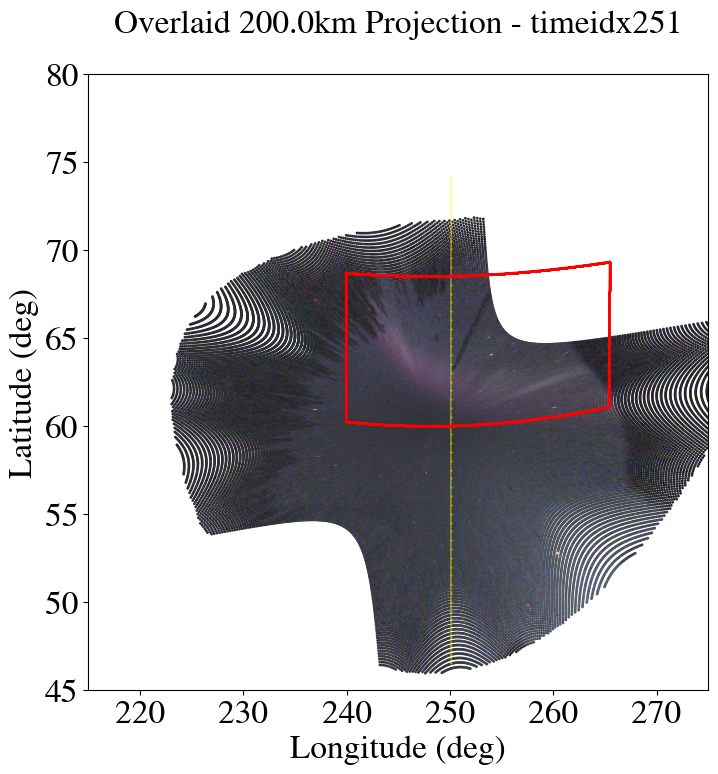

NameError: name 'lon_to_slice' is not defined

In [11]:
#-------var setup-----------#
#h_target_arr = [130000]

time_index = 251
site_name_yknf = "Yellowknife"
site_name_fsmi = "Fort Smith"
R_fsmi = fsmi_rgb_asi_ds.image.sel(channel="R").isel(times=time_index).values

lat_cam_yknf = yknf_rgb_asi_ds.attrs["site_latitude"]
lon_cam_yknf = yknf_rgb_asi_ds.attrs["site_longitude"]
full_elevation_yknf = yknf_rgb_asi_ds["elevation"]
full_azimuth_yknf = yknf_rgb_asi_ds["azimuth"]

lat_cam_fsmi = fsmi_rgb_asi_ds.attrs["site_latitude"]
lon_cam_fsmi = fsmi_rgb_asi_ds.attrs["site_longitude"]
full_elevation_fsmi = fsmi_rgb_asi_ds["elevation"]
full_azimuth_fsmi = fsmi_rgb_asi_ds["azimuth"]

# needed to get spherical intensity slice plots; want a box that covers BOTH of these areas (aka union of yknf and fsmi)
# fsmi
# latmin: 60.5
# latmax: 67.5
# lonmin: 241.5
# lonmax: 262.5

# yknf:
# latmin: 60
# latmax: 68.5
# lonmin: 240
# lonmax: 265

lat_box_min = 60
lat_box_max = 68.5
lon_box_min = 240
lon_box_max = 265


# reference longitude grid to use for the rest of the altitude projections (union of the 2 camera grids)
# want the reference altitude to be somehwere in the middle of all altitudes we are testing for; code will project up and down 
# need to change the initial lat/lon box min/max accordingly 
H_REF = 200000
yknf_lat_ref, yknf_lon_ref = altitude_helper.new_spherical_project_lat_lon(
    full_azimuth_yknf, full_elevation_yknf,
    lat_cam_yknf, lon_cam_yknf,
    H_REF
)

fsmi_lat_ref, fsmi_lon_ref = altitude_helper.new_spherical_project_lat_lon(
    full_azimuth_fsmi, full_elevation_fsmi,
    lat_cam_fsmi, lon_cam_fsmi,
    H_REF
)

lat_step = 0.5
GLOBAL_LAT_MIN = int(np.floor(
    min(np.nanmin(yknf_lat_ref), np.nanmin(fsmi_lat_ref))
))

GLOBAL_LAT_MAX = int(np.ceil(
    max(np.nanmax(yknf_lat_ref), np.nanmax(fsmi_lat_ref))
))

# array of corresp. latitudes to slice at and get the max intensity --> is projected upwards for each longitude slice 
global_lat_arr = np.arange(
    GLOBAL_LAT_MIN,
    GLOBAL_LAT_MAX + lat_step,
    lat_step
)

#--------project chosen az/el to get longitude to slice at for the different altitudes---------#
az_guess_yknf = np.array([85.0]) #deg --> these are eyeballed from yknf plot, so need to project using lat/lon of yknf! could do equiv for fsmi as a sanity check
el_guess_yknf = np.array([40.0]) #deg

# get the fixed geographic anchor point at H_REF
_, lon_ref_anchor = altitude_helper.new_spherical_project_lat_lon(
    az_guess_yknf, el_guess_yknf, lat_cam_yknf, lon_cam_yknf, H_REF
)
lon_anchor = lon_ref_anchor[0]    

for h_target in h_target_arr:
    global_lon_arr = [lon_anchor] # MODIFIED SO NOT ALREADY PROJECTING (shifting in the box was caused by projecting TWICE! once here and once in project_lon_slices_and_box (all projection happening in that func now)
    
    #--------project yknf and fsmi to each h_target-----------#
    #----- YKNF ------ #
    yknf_lat_proj_arr, yknf_lon_proj_arr = altitude_helper.new_spherical_project_lat_lon(full_azimuth_yknf, 
                                                                         full_elevation_yknf,
                                                                         lat_cam_yknf,
                                                                         lon_cam_yknf,
                                                                         h_target,
                                                                        )
    
    #----- FSMI ------ #
    fsmi_lat_proj_arr, fsmi_lon_proj_arr = altitude_helper.new_spherical_project_lat_lon(full_azimuth_fsmi, 
                                                                             full_elevation_fsmi,
                                                                             lat_cam_fsmi,
                                                                             lon_cam_fsmi,
                                                                             h_target,
                                                                            )

    #--------get rgb values for yknf and fsmi for plotting-----------#
    rgb_yknf, rgb_fsmi = altitude_helper.mod_plot_lat_lon(yknf_rgb_asi_ds, fsmi_rgb_asi_ds, time_index, site_name_yknf, site_name_fsmi, yknf_lat_proj_arr, yknf_lon_proj_arr, fsmi_lat_proj_arr, yknf_lon_proj_arr, h_target)

    yknf_lat_grid, yknf_R_intensity_interp = new_get_intensity_slice(yknf_lat_proj_arr, yknf_lon_proj_arr, rgb_yknf, 
                                                                 lat_box_max, lat_box_min, lon_box_max, lon_box_min,
                                                                 lat_cam_yknf, lon_cam_yknf,
                                                                 "YKNF", time_index, 
                                                                 H_REF, h_target,
                                                                 global_lon_arr, global_lat_arr)

    #---------intensity slice plot for each lon_to_slice---------#
    fsmi_lat_grid, fsmi_R_intensity_interp = new_get_intensity_slice(fsmi_lat_proj_arr, fsmi_lon_proj_arr, rgb_fsmi,
                                                                 lat_box_max, lat_box_min, lon_box_max, lon_box_min,
                                                                 lat_cam_fsmi, lon_cam_fsmi, 
                                                                "FSMI", time_index,
                                                                 H_REF, h_target,
                                                                global_lon_arr, global_lat_arr)

    #---------- overlaid yknf and fsmi plot of r channel intensity over latitude at a given projected-up longitude------------#
    plot_intensity_slice(yknf_lat_grid, yknf_R_intensity_interp,
                        fsmi_lat_grid, fsmi_R_intensity_interp,
                        lon_to_slice, h_target)

   # print(fsmi_lat_grid)
   # print(fsmi_R_intensity_interp)
    

    # #---------overlaid yknf and fsmi with a line at the longitude lon_to_slice----------------#
    # altitude_helper.lon_line_plot(yknf_rgb_asi_ds, fsmi_rgb_asi_ds, time_index, site_name_yknf, site_name_fsmi, 
    #               yknf_lat_proj_arr, yknf_lon_proj_arr, fsmi_lat_proj_arr, fsmi_lon_proj_arr, 
    #               h_target, lon_to_slice)

    # #----------overlaid yknf and fsmi with a diagonal cutoff to better see overlap-----------#
    # plot_overlaid_masked(yknf_rgb_asi_ds, fsmi_rgb_asi_ds, time_index,
    #                      site_name_yknf, site_name_fsmi, 
    #                      yknf_lat_proj_arr, yknf_lon_proj_arr, fsmi_lat_proj_arr, fsmi_lon_proj_arr,
    #                      h_target)
    